In [44]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [45]:
from PIL import Image

In [46]:
(x_train,y_train), (x_test,y_test) = mnist.load_data()

In [47]:
x_train.shape

(60000, 28, 28)

In [48]:
y_train.shape

(60000,)

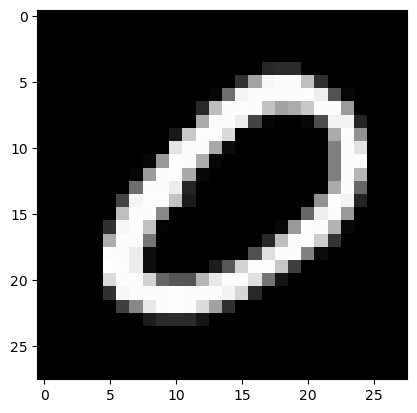

In [49]:
plt.imshow(x_train[453], cmap='gray')

In [50]:
sample_img = x_train[453]

In [51]:
print("top left cornner of img 1\n",sample_img[0:15, 0:15])

top left cornner of img 1
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   6 110]
 [  0   0   0   0   0   0   0   0   0   0   0   0  41 190 252]
 [  0   0   0   0   0   0   0   0   0   0   0   0 171 252 252]
 [  0   0   0   0   0   0   0   0   0   0  25 201 253 253 218]
 [  0   0   0   0   0   0   0   0   0   0 227 252 252 169  11]
 [  0   0   0   0   0   0   0   0   6 153 253 252 171   7   0]
 [  0   0   0   0   0   0   0   6 155 252 253 169   7   0   0]
 [  0   0   0   0   0   0   0 110 252 252 236  37   0   0   0]
 [  0   0   0   0   0   0  68 245 253 253 194  27   0   0   0]]


In [52]:
#Normailze Pixel value b/w 0-1
x_train_norm = x_train.astype('float32')/255.0 #all the 60k images are normalized
x_test_norm = x_test.astype('float32')/255.0 #all the 10k images are normalized

In [53]:
print("top left cornner of img 1\n",x_train_norm[453][0:15, 0:15])

top left cornner of img 1
 [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.

In [54]:
x_train_norm.min() #min pixel value after normalization

np.float32(0.0)

In [55]:
x_train_norm.max() #max pixel value after normalization

np.float32(1.0)

In [56]:
print("top left cornner of img 1\n",x_train_norm[453][0:15, 0:15])

top left cornner of img 1
 [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.

In [57]:
# demo_convolution = layers.Conv2D(filters=1,kernel_size=(3,3),activation='relu')
# Since the image is very large, supplying only with 1 filter it become time consuming

In [58]:
demo_convolution = layers.Conv2D(filters=4,kernel_size=(3,3),activation='relu')

In [59]:
demo_pooling = layers.MaxPool2D(pool_size=(2,2))

In [60]:
one_img = x_train_norm[0:1]

In [61]:
one_img = np.expand_dims(one_img,axis=-1)
conv_output = demo_convolution(one_img)

In [62]:
pool_output = demo_pooling(conv_output)

In [63]:
conv_output.shape

TensorShape([1, 26, 26, 4])

In [64]:
pool_output.shape

TensorShape([1, 13, 13, 4])

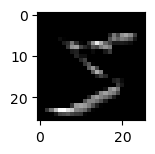

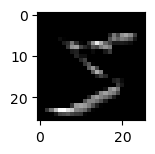

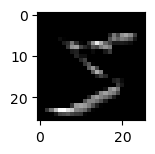

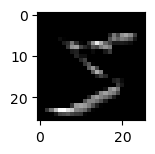

In [65]:
plt.Figure(figsize=(10,10))

for i in range( 4):
    plt.subplot(1,4,i+1)
    plt.imshow(conv_output[0,:,:,1],cmap='gray')
    plt.show()


In [66]:
demo_flatten = layers.Flatten()

flatten_output = demo_flatten(pool_output)

In [67]:
flatten_output.shape

TensorShape([1, 676])

if the current dimention of this input image is 13x13 how will it change after 2nd convolution layer and 2nd pooling layer given kernel 3x3 and pool size is 2x2

In [71]:
#building the CNN Inages Classifier
model = models.Sequential([
    layers.Input(shape=(28,28,2),name='input layer'),
    layers.Conv2D(filters=16,kernel_size=(3,3), activation='relu', name='conv_laye_1'),
    layers.MaxPool2D(pool_size=(2,2), name="max_pool_1"),#[1,13,13,16]
    layers.Conv2D(filters=32,kernel_size=(3,3), activation='relu', name='conv_laye_2'),
    layers.MaxPool2D(pool_size=(2,2), name="max_pool_2"),#[1,5,5,32]
    layers.Flatten(name='faltten_layer'),#5x5x32 = 800 values
    layers.Dense(64,  activation='relu', name='hidden_layer_1'),
    layers.Dense(32,  activation='relu', name='hidden_layer_2'),
    layers.Dense(units=10, activation='softmax',name='output_layer')    
])